#### Optimizer r08: introduces fleet mode: baseline and expanded. 

This notebook runs the linearized OC Transpo optimizer and adds a clean sensitivity-analysis workflow for route bar graphs, with fleet-cap scenarios.

Main ideas:
- keep all tuning in one place,
- solve one scenario through one function,
- vary one parameter over a list of values,
- plot all routes and selected routes.


In [281]:

from pathlib import Path
import copy
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.demand_linear import LinearDemandModel
from src.costs import CostModel
from src.benefits_linear import LinearBenefitModel

pd.set_option('display.max_rows', 200)
pd.set_option('display.max_columns', 100)
pd.set_option('display.float_format', lambda x: f'{x:,.3f}')

try:
    import gurobipy as gp
    from gurobipy import GRB, quicksum
except ModuleNotFoundError as e:
    raise ModuleNotFoundError(
        'gurobipy is not installed in this environment. Run this notebook in your local project environment.'
    ) from e


#### Controls

Tweak inputs / parameters and run sensitivity analysis

In [282]:
ROUTES_OF_INTEREST = ['10', '111', '48', '7']
TIME_BLOCKS = ['Early AM', 'AM Peak', 'Midday', 'PM Peak', 'Evening', 'Night']

FLEET_SCENARIO_SETUP = {
    'mode': 'expanded',   # 'baseline' or 'expanded'
}
# base scenario should be super simple. sets all the default values for all parameters.
BASE_SCENARIO = {
    'max_change_by_route_type': {
        'Frequent': 4,
        'Local': 2,
        'Connexion': 2,
    },
    'expansion_factor': 1.1, # i.e. 1.2 meaning 20% increase
    'fleet_caps': None, # Use None to let FLEET_SCENARIO_SETUP choose baseline/expanded automatically. Or provide an explicit dict in this format to override manually.
    # 'fleet_caps': DEFAULT_FLEET_CAPS.copy(),
    # by default, none will give the n_old totals so that 'fleet_caps': {
    #     'Early AM': 89,
    #     'AM Peak': 231,
    #     'Midday': 169,
    #     'PM Peak': 258,
    #     'Evening': 113,
    #     'Night': 55,
    # },
    'budget_total': 50000.0,
    'demand_elasticity': 0.5,
    'W_driver_multiplier': 1.0,
    'P_fuel_multiplier': 1.0,
    'fuel_consumption_multiplier': 1.0,
    'P_maintenance_multiplier': 1.0,
    'W_passenger_multiplier': 1.0,
    'F_wage_multiplier': 1.0,
    'I_GHG_car_multiplier': 1.0,
    'L_avg_trip_multiplier': 1.0,
    'SCC_multiplier': 1.0,
}

# comment out the parameters not being studied,, and then set values for the parameter(s) being studied. 
SENSITIVITY_SETUP = {
    'parameter_name': 'expansion_factor',  # the name of the parameter to be studied. should match a key in BASE_SCENARIO.
    'values': [0.8, 1.0, 1.2, 1.4], # the values of the parameter to be studied. should be a list of values to iterate through.

    # examples:

    # 'budget_total'
    # 'fleet_cap_all_blocks'
    # 'fleet_cap_AM Peak' 
    # 'W_driver_multiplier'
    # 'P_fuel_multiplier'
    # 'fuel_consumption_multiplier'
    # 'P_maintenance_multiplier'
    # 'W_passenger_multiplier'
    # 'F_wage_multiplier'
    # 'I_GHG_car_multiplier'
    # 'L_avg_trip_multiplier'
    # 'SCC_multiplier'
}

GRAPH_SETUP = {
    'time_block': 'AM Peak', # i.e. 'AM Peak'
    'value_col': 'n_new',
    'sort_routes_numeric': True,
}


#### Load and clean data

In [283]:
#helper to find the first existing file path from a list of candidates, or raise an error if none are found
def first_existing_path(candidates):
    path = next((Path(p) for p in candidates if Path(p).exists()), None)
    if path is None:
        raise FileNotFoundError(f'Could not find any of: {candidates}')
    return path


def load_and_clean_data():
    route_data_path = first_existing_path([
        'data/route_timeblock_v02.csv',
        'data/route_timeblock_subset_v02.csv',
        'data/route_timeblock_subset_v01.csv',
        '/mnt/data/route_timeblock_subset_v01.csv',
    ])

    raw_df = pd.read_csv(route_data_path)

    col_map = {
        'Route (r)': 'route',
        'Time Block (t)': 'time_block',
        'Route type': 'route_type',
        'Old ridership (x_old,r,t)': 'x_old',
        'Trip length km (L_r)': 'L_r',
        'Average length hr (T_r,t)': 'T_rt',
        'Old frequency of buses (f_old,r,t)': 'f_old',
        'Old number of buses (n_old,r,t) - continuous': 'n_old_cont',
        'Old number of buses (n_old,r,t) - discrete': 'n_old',
        'Time block hr (H_block,t)': 'H_block',
        'Driver horuly wage rate $/hr (W_driver)': 'W_driver',
        'Price of fuel $/litre (P_fuel)': 'P_fuel',
        'Fuel consumption (FC)': 'fuel_consumption',
        'Maintenace cost $/km (P_maintenance)': 'P_maintenance',
        'Passenger hourly wage rate $/hr (W_passenger)': 'W_passenger',
        'VTTS fraction of passenger wage (F_wage)': 'F_wage',
        'Emission intensity of a car kgCO2eq/KPT (I_GHG,car)': 'I_GHG_car',
        'Average Length of passenger trip (L_avg_trip)': 'L_avg_trip',
        'Social cost of carbon $/tonne CO2eq (SCC)': 'SCC',
    }

    df = raw_df.rename(columns=col_map).copy()

    required_cols = [
        'route', 'time_block', 'route_type',
        'x_old', 'L_r', 'T_rt', 'f_old',
        'n_old_cont', 'n_old',
        'H_block', 'W_driver', 'P_fuel',
        'fuel_consumption', 'P_maintenance',
        'W_passenger', 'F_wage',
        'I_GHG_car', 'L_avg_trip', 'SCC'
    ]

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise KeyError(f'Missing expected columns: {missing}')

    df['route'] = df['route'].astype(str).str.strip()
    df['time_block'] = df['time_block'].astype(str).str.strip()
    df['route_type'] = df['route_type'].astype(str).str.strip()

    cancelled_mask = df['route_type'].str.lower().eq('cancelled')
    df = df.loc[~cancelled_mask].copy()

    numeric_cols = [
        'x_old', 'L_r', 'T_rt', 'f_old',
        'n_old_cont', 'n_old',
        'H_block', 'W_driver', 'P_fuel',
        'fuel_consumption', 'P_maintenance',
        'W_passenger', 'F_wage',
        'I_GHG_car', 'L_avg_trip', 'SCC'
    ]
    for c in numeric_cols:
        df[c] = pd.to_numeric(df[c], errors='coerce')

    df['n_old'] = df['n_old'].round().astype(int)
    df['time_block'] = pd.Categorical(df['time_block'], categories=TIME_BLOCKS, ordered=True)
    df = df.sort_values(['route', 'time_block']).reset_index(drop=True)
    df['key'] = list(zip(df['route'], df['time_block'].astype(str)))

    return df, route_data_path


df, route_data_path = load_and_clean_data()
print(f'Using route-time data: {route_data_path}')
df.head()


baseline_fleet_caps = (
    df.groupby('time_block', observed=True)['n_old']
    .sum()
    .astype(int)
    .to_dict()
)

BASE_SCENARIO_ACTIVE = copy.deepcopy(BASE_SCENARIO)

# choose expansion factor from scenario (this is the key change)
expansion = BASE_SCENARIO_ACTIVE['expansion_factor']

expanded_fleet_caps = {
    t: int(math.ceil(baseline_fleet_caps[t] * expansion))
    for t in TIME_BLOCKS
}

if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = baseline_fleet_caps.copy()

elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
    BASE_SCENARIO_ACTIVE['fleet_caps'] = expanded_fleet_caps.copy()

else:
    raise ValueError("FLEET_SCENARIO_SETUP['mode'] must be 'baseline' or 'expanded'")

print(f"Using fleet scenario: {FLEET_SCENARIO_SETUP['mode']}")
print(f"Fleet caps: {BASE_SCENARIO_ACTIVE['fleet_caps']}")


Using route-time data: data\route_timeblock_v02.csv
Using fleet scenario: expanded
Fleet caps: {'Early AM': 98, 'AM Peak': 255, 'Midday': 186, 'PM Peak': 284, 'Evening': 125, 'Night': 61}


#### Scenario helpers

In [284]:
#helper to create a new scenario dict by overriding a specified parameter in the base scenario with a new value, including special handling for fleet capacity parameters which can be set for all time blocks or individually by time block.
def scenario_with_override(base_scenario, parameter_name, parameter_value):
    scenario = copy.deepcopy(base_scenario)
    # print(f"val={val}, expansion={scenario.get('expansion_factor')}, caps={scenario['fleet_caps']}")

    if parameter_name == 'fleet_cap_all_blocks':
        if scenario['fleet_caps'] is None:
            if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
                scenario['fleet_caps'] = baseline_fleet_caps.copy()
            elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
                expansion = scenario.get('expansion_factor', 1.0)
                scenario['fleet_caps'] = {
                    t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                    for t in TIME_BLOCKS
                }

        for t in scenario['fleet_caps']:
            scenario['fleet_caps'][t] = int(parameter_value)
        return scenario

    if parameter_name.startswith('fleet_cap_'):
        if scenario['fleet_caps'] is None:
            if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
                scenario['fleet_caps'] = baseline_fleet_caps.copy()
            elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
                expansion = scenario.get('expansion_factor', 1.0)
                scenario['fleet_caps'] = {
                    t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                    for t in TIME_BLOCKS
                }

        block = parameter_name.replace('fleet_cap_', '', 1)
        if block not in scenario['fleet_caps']:
            raise KeyError(f'Unknown time block in parameter name: {parameter_name}')
        scenario['fleet_caps'][block] = int(parameter_value)
        return scenario

    if parameter_name not in scenario:
        raise KeyError(f'Unsupported parameter: {parameter_name}')

    scenario[parameter_name] = parameter_value

    if scenario.get('fleet_caps') is None:
        if FLEET_SCENARIO_SETUP['mode'] == 'baseline':
            scenario['fleet_caps'] = baseline_fleet_caps.copy()
        elif FLEET_SCENARIO_SETUP['mode'] == 'expanded':
            expansion = scenario.get('expansion_factor', 1.0)
            scenario['fleet_caps'] = {
                t: int(math.ceil(baseline_fleet_caps[t] * expansion))
                for t in TIME_BLOCKS
            }

    return scenario

#### Build model inputs

In [285]:
#helper to build all the inputs for the optimization model from the scenario and dataframe, including applying multipliers, computing alpha/beta parameters, and validating that all necessary data is present and consistent.
def build_inputs_from_scenario(df, scenario):
    R = sorted(df['route'].unique().tolist())
    T = list(df['time_block'].cat.categories)
    RT = [(r, t) for r in R for t in T]

    missing = set(RT) - set(df['key'])
    if missing:
        raise ValueError(f'Missing route-time combinations: {sorted(missing)}')

    route_types_in_df = sorted(df['route_type'].dropna().unique())
    missing_route_types = sorted(set(route_types_in_df) - set(scenario['max_change_by_route_type'].keys()))
    if missing_route_types:
        raise KeyError(f'Missing max-change caps for route types: {missing_route_types}')

    df2 = df.copy()

    df2['W_driver_eff'] = df2['W_driver'] * scenario['W_driver_multiplier']
    df2['P_fuel_eff'] = df2['P_fuel'] * scenario['P_fuel_multiplier']
    df2['fuel_consumption_eff'] = df2['fuel_consumption'] * scenario['fuel_consumption_multiplier']
    df2['P_maintenance_eff'] = df2['P_maintenance'] * scenario['P_maintenance_multiplier']
    df2['W_passenger_eff'] = df2['W_passenger'] * scenario['W_passenger_multiplier']
    df2['F_wage_eff'] = df2['F_wage'] * scenario['F_wage_multiplier']
    df2['I_GHG_car_eff'] = df2['I_GHG_car'] * scenario['I_GHG_car_multiplier']
    df2['L_avg_trip_eff'] = df2['L_avg_trip'] * scenario['L_avg_trip_multiplier']
    df2['SCC_eff'] = df2['SCC'] * scenario['SCC_multiplier']

    x_old = df2.set_index('key')['x_old'].to_dict()
    n_old = df2.set_index('key')['n_old'].astype(int).to_dict()
    T_rt = df2.set_index('key')['T_rt'].to_dict()
    route_type = df2.set_index('key')['route_type'].to_dict()

    L_r = df2.groupby('route')['L_r'].first().to_dict()
    H_block = df2.groupby('time_block')['H_block'].first().to_dict()

    W_driver = float(df2['W_driver_eff'].iloc[0])
    P_fuel = float(df2['P_fuel_eff'].iloc[0])
    P_maintenance = float(df2['P_maintenance_eff'].iloc[0])
    fuel_consumption = float(df2['fuel_consumption_eff'].mean())

    alpha = {}
    beta_time = {}
    beta_emissions = {}
    n_min = {}
    n_max = {}
    frozen_zero_keys = []
    RT_opt = []

    eps = scenario['demand_elasticity']

    for _, row in df2.iterrows():
        r = row['route']
        t = str(row['time_block'])
        k = (r, t)

        x0 = float(row['x_old'])
        T0 = float(row['T_rt'])
        n0 = int(row['n_old'])
        rt_type = row['route_type']

        if pd.isna(T0) or T0 < 0:
            raise ValueError(f'Invalid T_rt for key {k}: {T0}')

        if n0 <= 0:
            alpha[k] = 0.0
            beta_time[k] = 0.0
            beta_emissions[k] = 0.0
            n_min[k] = 0
            n_max[k] = 0
            frozen_zero_keys.append(k)
            continue

        if T0 <= 0:
            raise ValueError(f'T_rt must be positive when n_old > 0 for key {k}')

        delta_cap = int(scenario['max_change_by_route_type'][rt_type])
        n_min[k] = max(0, n0 - delta_cap)
        n_max[k] = n0 + delta_cap

        alpha[k] = eps * x0 / n0
        beta_time[k] = x0 * float(row['W_passenger_eff']) * float(row['F_wage_eff']) * (0.5 * T0 / (n0 ** 2))
        beta_emissions[k] = alpha[k] * float(row['L_avg_trip_eff']) * float(row['I_GHG_car_eff']) * float(row['SCC_eff']) / 1000.0

        RT_opt.append(k)

    return {
        'R': R,
        'T': T,
        'RT': RT,
        'RT_opt': RT_opt,
        'x_old': x_old,
        'n_old': n_old,
        'T_rt': T_rt,
        'route_type': route_type,
        'L_r': L_r,
        'H_block': H_block,
        'W_driver': W_driver,
        'P_fuel': P_fuel,
        'fuel_consumption': fuel_consumption,
        'P_maintenance': P_maintenance,
        'alpha': alpha,
        'beta_time': beta_time,
        'beta_emissions': beta_emissions,
        'n_min': n_min,
        'n_max': n_max,
        'fleet_caps': scenario['fleet_caps'],
        'budget_total': scenario['budget_total'],
        'frozen_zero_keys': frozen_zero_keys,
    }


#### Solve one scenario

In [286]:

#consstruct optimization problem based on formulation from /src and solve it, returning the solution and summary statistics in a structured format
def solve_scenario(df, scenario, model_name='oc_transpo_linearized_r08', output_flag=0):
    data = build_inputs_from_scenario(df, scenario)




    #-------------------------------------------------------------------------------------------------------
    #
    #
    # Model / Obj Function

    demand_model = LinearDemandModel(
        alpha=data['alpha'],
        n_old=data['n_old'],
        x_old=data['x_old'],
    )

    cost_model = CostModel(
        H_block=data['H_block'],
        W_driver=data['W_driver'],
        L_r=data['L_r'],
        T_rt=data['T_rt'],
        P_fuel=data['P_fuel'],
        fuel_consumption=data['fuel_consumption'],
        P_maintenance=data['P_maintenance'],
        n_old=data['n_old'],
    )

    benefit_model = LinearBenefitModel(
        beta_time=data['beta_time'],
        beta_emissions=data['beta_emissions'],
        n_old=data['n_old'],
    )

    # Build and solve optimization model based on the data and models
    m = gp.Model(model_name)
    m.Params.OutputFlag = output_flag

    # Decision variables: n_new[r,t] for each route-time in RT_opt
    n_new = m.addVars(
        data['RT_opt'],
        vtype=GRB.INTEGER,
        lb={k: data['n_min'][k] for k in data['RT_opt']},
        ub={k: data['n_max'][k] for k in data['RT_opt']},
        name='n_new',
    )
 
    # Objective: minimize total cost minus total benefit across all route-times in RT_opt
    objective = quicksum(
        cost_model.total(r, t, n_new[r, t]) - benefit_model.benefit_total(r, t, n_new[r, t])
        for r, t in data['RT_opt']
    )
    m.setObjective(objective, GRB.MINIMIZE)


    #-------------------------------------------------------------------------------------------------------
    #
    #
    # Constraints: 
    fleet_constraints = {
        t: m.addConstr(
            quicksum(n_new[r, tb] for (r, tb) in data['RT_opt'] if tb == t) <= data['fleet_caps'][t],
            name=f'fleet[{t}]'
        )
        for t in data['T']
    }

    m.addConstr(
        quicksum(cost_model.total(r, t, n_new[r, t]) for r, t in data['RT_opt']) <= data['budget_total'],
        name='budget_total_operational'
    )

    m.optimize()

    if m.Status != GRB.OPTIMAL:
        raise RuntimeError(f'Model did not solve to optimality. Status = {m.Status}')

    rows = []

    for r, t in data['RT']:
        active = (r, t) in data['RT_opt']

        if active:
            n_star = int(round(n_new[r, t].X))
            x_new = demand_model.ridership(r, t, n_star)
            delta_x = demand_model.delta_ridership(r, t, n_star)
            cost_delta = cost_model.total(r, t, n_star)
            benefit_time_delta = benefit_model.benefit_time(r, t, n_star)
            benefit_emissions_delta = benefit_model.benefit_emissions(r, t, n_star)
            benefit_total_delta = benefit_model.benefit_total(r, t, n_star)
            net_contrib = cost_delta - benefit_total_delta
        else:
            n_star = 0
            x_new = data['x_old'][(r, t)]
            delta_x = 0.0
            cost_delta = 0.0
            benefit_time_delta = 0.0
            benefit_emissions_delta = 0.0
            benefit_total_delta = 0.0
            net_contrib = 0.0

        rows.append({
            'route': r,
            'time_block': t,
            'route_type': data['route_type'][(r, t)],
            'active_in_model': active,
            'n_old': data['n_old'][(r, t)],
            'n_new': n_star,
            'delta_n': n_star - data['n_old'][(r, t)],
            'x_old': data['x_old'][(r, t)],
            'x_new_linear': x_new,
            'delta_ridership': delta_x,
            'operating_cost_delta': cost_delta,
            'benefit_time_delta': benefit_time_delta,
            'benefit_emissions_delta': benefit_emissions_delta,
            'benefit_total_delta': benefit_total_delta,
            'net_objective_contribution': net_contrib,
            'at_lower_bound': n_star == data['n_min'][(r, t)],
            'at_upper_bound': n_star == data['n_max'][(r, t)],
        })

    solution_df = pd.DataFrame(rows)

    summary = {
        'objective_value': m.ObjVal,
        'budget_total': data['budget_total'],
        'budget_used': solution_df['operating_cost_delta'].sum(),
        'budget_slack': data['budget_total'] - solution_df['operating_cost_delta'].sum(),
        'total_delta_ridership': solution_df['delta_ridership'].sum(),
        'total_cost_delta': solution_df['operating_cost_delta'].sum(),
        'total_time_benefit_delta': solution_df['benefit_time_delta'].sum(),
        'total_emissions_benefit_delta': solution_df['benefit_emissions_delta'].sum(),
        'total_benefit_delta': solution_df['benefit_total_delta'].sum(),
        'vars_at_lower_bound': int(solution_df['at_lower_bound'].sum()),
        'vars_at_upper_bound': int(solution_df['at_upper_bound'].sum()),
        'runtime_seconds': m.Runtime,
        'node_count': m.NodeCount,
        'mip_gap': m.MIPGap,
        'solver_status': m.Status,
        'sol_count': m.SolCount,
        'iter_count': m.IterCount,
        'num_vars': m.NumVars,
        'num_constrs': m.NumConstrs,    
    }

    for t in data['T']:
        used = int(solution_df.loc[solution_df['time_block'] == t, 'n_new'].sum())
        cap = data['fleet_caps'][t]
        summary[f'fleet_used[{t}]'] = used
        summary[f'fleet_cap[{t}]'] = cap
        summary[f'fleet_slack[{t}]'] = cap - used

    return {
        'model': m,
        'solution_df': solution_df,
        'summary': pd.Series(summary),
        'scenario': copy.deepcopy(scenario),
    }


#### Run sensitivity

In [287]:

def run_sensitivity(df, base_scenario, parameter_name, values, output_flag=0):
    route_level_results = []
    scenario_summaries = []
    full_solution_results = []

    for val in values:
        scenario = scenario_with_override(base_scenario, parameter_name, val)
        result = solve_scenario(df, scenario, output_flag=output_flag)

        sol = result['solution_df'].copy()
        sol['sensitivity_parameter'] = parameter_name
        sol['parameter_value'] = val
        full_solution_results.append(sol)

        route_summary = (
            sol.groupby('route', as_index=False)
              .agg(
                  n_old_total=('n_old', 'sum'),
                  n_new_total=('n_new', 'sum'),
                  delta_n_total=('delta_n', 'sum'),
                  delta_ridership_total=('delta_ridership', 'sum'),
                  operating_cost_delta_total=('operating_cost_delta', 'sum'),
                  benefit_total_delta_total=('benefit_total_delta', 'sum'),
              )
        )
        route_summary['sensitivity_parameter'] = parameter_name
        route_summary['parameter_value'] = val
        route_level_results.append(route_summary)

        summary_row = result['summary'].to_dict()
        summary_row['sensitivity_parameter'] = parameter_name
        summary_row['parameter_value'] = val
        scenario_summaries.append(summary_row)

    all_route_results = pd.concat(route_level_results, ignore_index=True)
    all_solution_results = pd.concat(full_solution_results, ignore_index=True)
    all_summaries = pd.DataFrame(scenario_summaries)

    return all_route_results, all_solution_results, all_summaries


#### Plot helpers

In [288]:
def aggregate_for_plot(solution_results, time_block='all', value_col='n_new'):
    if value_col not in ['n_new', 'delta_n']:
        raise ValueError("value_col must be 'n_new' or 'delta_n'")

    df_plot = solution_results.copy()

    if time_block != 'all':
        if time_block not in df_plot['time_block'].unique():
            raise ValueError(f"Unknown time_block: {time_block}")
        df_plot = df_plot[df_plot['time_block'] == time_block].copy()

    grouped = (
        df_plot.groupby(['route', 'parameter_value'], as_index=False)[value_col]
        .sum()
    )

    return grouped


def sort_route_index(index_vals):
    return sorted(
        index_vals,
        key=lambda x: int(x) if str(x).isdigit() else str(x)
    )


def make_plot_pivot(solution_results, time_block='all', value_col='n_new', route_filter=None, sort_routes_numeric=True):
    grouped = aggregate_for_plot(
        solution_results=solution_results,
        time_block=time_block,
        value_col=value_col,
    )

    if route_filter is not None:
        grouped = grouped[grouped['route'].isin(route_filter)].copy()

    pivot = grouped.pivot(index='route', columns='parameter_value', values=value_col)

    if route_filter is not None:
        pivot = pivot.reindex(route_filter)
    elif sort_routes_numeric:
        pivot = pivot.reindex(sort_route_index(pivot.index))

    return pivot


def make_plot_labels(parameter_name, time_block='all', value_col='n_new'):
    block_label = 'all time blocks' if time_block == 'all' else time_block
    y_label = {
        'n_new': 'Bus allocation (n_new)',
        'delta_n': 'Bus change from baseline (delta_n)',
    }[value_col]
    return block_label, y_label


def plot_all_routes_bar(
    solution_results,
    parameter_name,
    time_block='all',
    value_col='n_new',
    figsize=(20, 8),
    sort_routes_numeric=True,
):
    pivot = make_plot_pivot(
        solution_results=solution_results,
        time_block=time_block,
        value_col=value_col,
        route_filter=None,
        sort_routes_numeric=sort_routes_numeric,
    )

    block_label, y_label = make_plot_labels(
        parameter_name=parameter_name,
        time_block=time_block,
        value_col=value_col,
    )

    ax = pivot.plot(kind='bar', figsize=figsize)
    ax.set_title(f'All routes: {value_col} by route | {block_label} | sensitivity: {parameter_name}')
    ax.set_xlabel('Route')
    ax.set_ylabel(y_label)
    ax.legend(title=parameter_name)

    if value_col == 'delta_n':
        ax.axhline(0, linewidth=1)

    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()


def plot_selected_routes_bar(
    solution_results,
    parameter_name,
    routes_of_interest,
    time_block='all',
    value_col='n_new',
    figsize=(10, 6),
):
    pivot = make_plot_pivot(
        solution_results=solution_results,
        time_block=time_block,
        value_col=value_col,
        route_filter=routes_of_interest,
        sort_routes_numeric=False,
    )

    block_label, y_label = make_plot_labels(
        parameter_name=parameter_name,
        time_block=time_block,
        value_col=value_col,
    )

    ax = pivot.plot(kind='bar', figsize=figsize)
    ax.set_title(f'Selected routes: {value_col} by route | {block_label} | sensitivity: {parameter_name}')
    ax.set_xlabel('Route')
    ax.set_ylabel(y_label)
    ax.legend(title=parameter_name)

    if value_col == 'delta_n':
        ax.axhline(0, linewidth=1)

    plt.xticks(rotation=0)
    plt.tight_layout()
    plt.show()

#### Run one sensitivity study

In [289]:
# run the sensitivity study and print the summary. !!!!!
route_results, solution_results, summary_results = run_sensitivity(
    df=df,
    base_scenario=BASE_SCENARIO,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    values=SENSITIVITY_SETUP['values'],
    output_flag=0,
)

# print summary ! 
summary_results


,objective_value,budget_total,budget_used,budget_slack,total_delta_ridership,total_cost_delta,total_time_benefit_delta,total_emissions_benefit_delta,total_benefit_delta,vars_at_lower_bound,vars_at_upper_bound,runtime_seconds,node_count,mip_gap,solver_status,sol_count,iter_count,num_vars,num_constrs,fleet_used[Early AM],fleet_cap[Early AM],fleet_slack[Early AM],fleet_used[AM Peak],fleet_cap[AM Peak],fleet_slack[AM Peak],fleet_used[Midday],fleet_cap[Midday],fleet_slack[Midday],fleet_used[PM Peak],fleet_cap[PM Peak],fleet_slack[PM Peak],fleet_used[Evening],fleet_cap[Evening],fleet_slack[Evening],fleet_used[Night],fleet_cap[Night],fleet_slack[Night],sensitivity_parameter,parameter_value
0,"-340,679.803","50,000.000","-46,887.110","96,887.110","26,814.526","-46,887.110","287,727.910","6,064.782","293,792.693",394.000,193.000,0.013,1.000,0.000,2.000,2.000,6.000,429.000,7.000,72.000,72.000,0.000,185.000,185.000,0.000,136.000,136.000,0.000,207.000,207.000,0.000,91.000,91.000,0.000,44.000,44.000,0.000,expansion_factor,0.800
1,"-435,382.294","50,000.000","-9,809.831","59,809.831","46,100.469","-9,809.831","413,317.778","12,254.685","425,572.463",361.000,225.000,0.010,1.000,0.000,2.000,2.000,6.000,429.000,7.000,89.000,89.000,0.000,231.000,231.000,0.000,169.000,169.000,0.000,258.000,258.000,0.000,113.000,113.000,0.000,55.000,55.000,0.000,expansion_factor,1.000
2,"-513,877.498","50,000.000","30,257.272","19,742.728","62,968.613","30,257.272","525,480.132","18,654.639","544,134.770",325.000,260.000,0.013,1.000,0.000,2.000,2.000,6.000,429.000,7.000,107.000,107.000,0.000,278.000,278.000,0.000,203.000,203.000,0.000,310.000,310.000,0.000,136.000,136.000,0.000,66.000,66.000,0.000,expansion_factor,1.200
3,"-554,661.455","50,000.000","49,990.019",9.981,"71,143.021","49,990.019","582,931.309","21,720.165","604,651.474",310.000,278.000,0.015,1.000,0.000,2.000,3.000,11.000,429.000,7.000,79.000,125.000,46.000,324.000,324.000,0.000,237.000,237.000,0.000,335.000,362.000,27.000,141.000,159.000,18.000,77.000,77.000,0.000,expansion_factor,1.400


#### Review outputs

In [290]:
# aggregate_for_plot(
#     solution_results=solution_results,
#     time_block=GRAPH_SETUP['time_block'],
#     value_col=GRAPH_SETUP['value_col'],
# ).head(20)

In [291]:

# solution_results[
#     solution_results['route'].isin(ROUTES_OF_INTEREST)
# ].sort_values(['parameter_value', 'route', 'time_block']).reset_index(drop=True)


#### Plot outputs

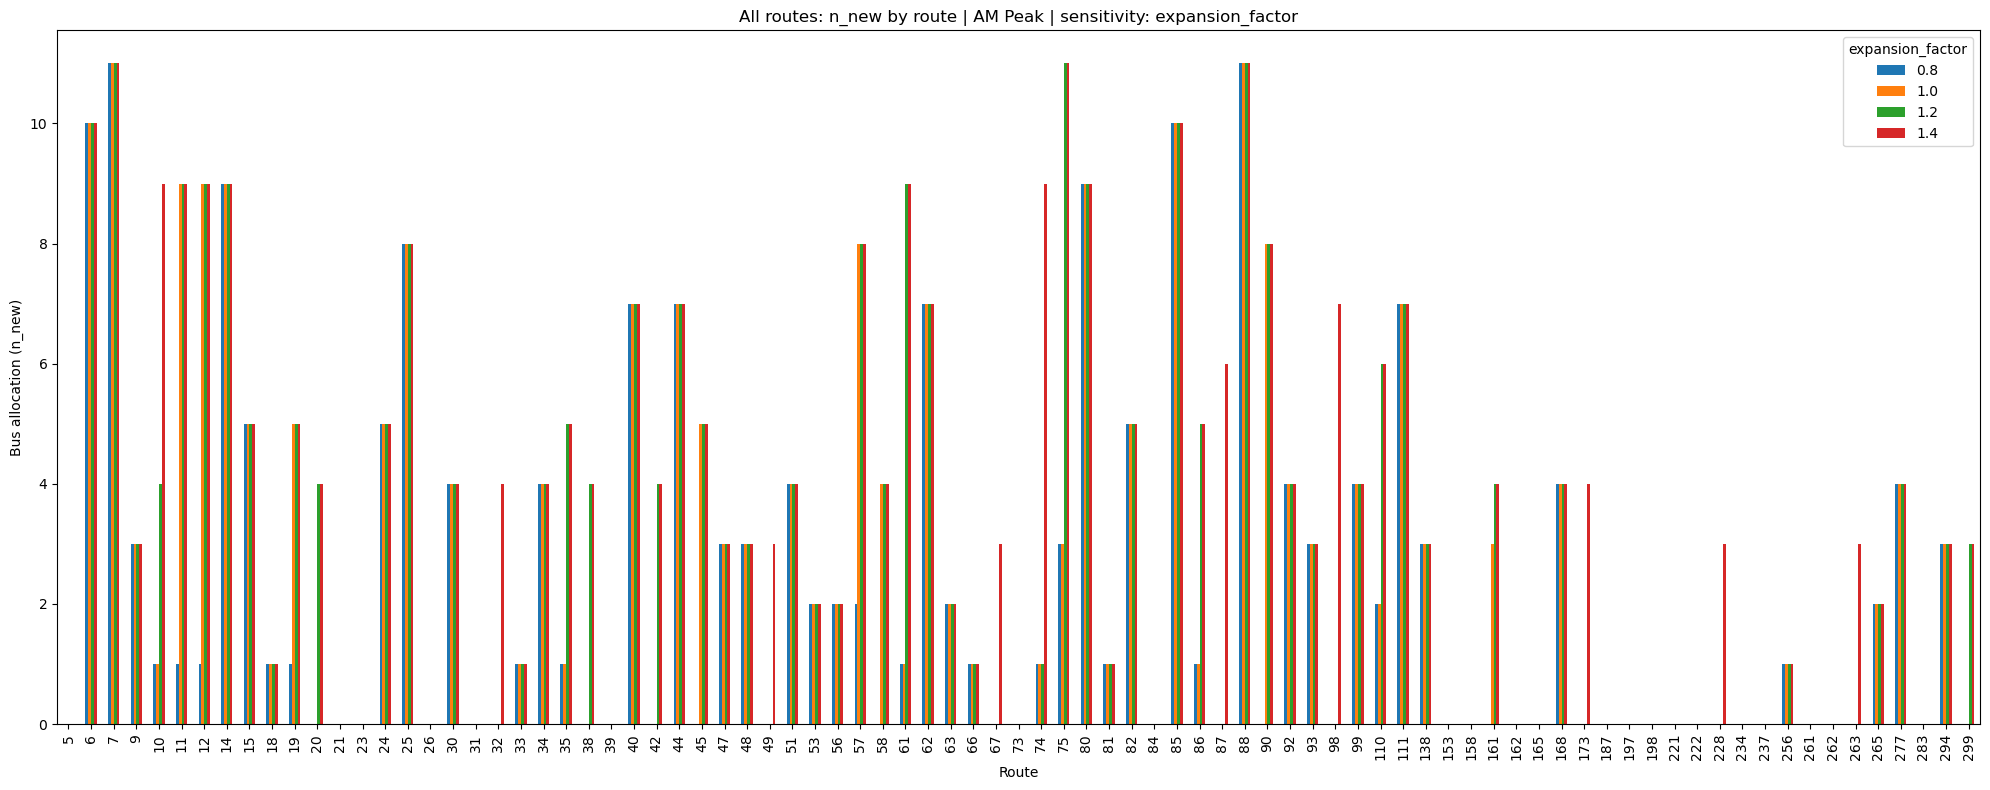

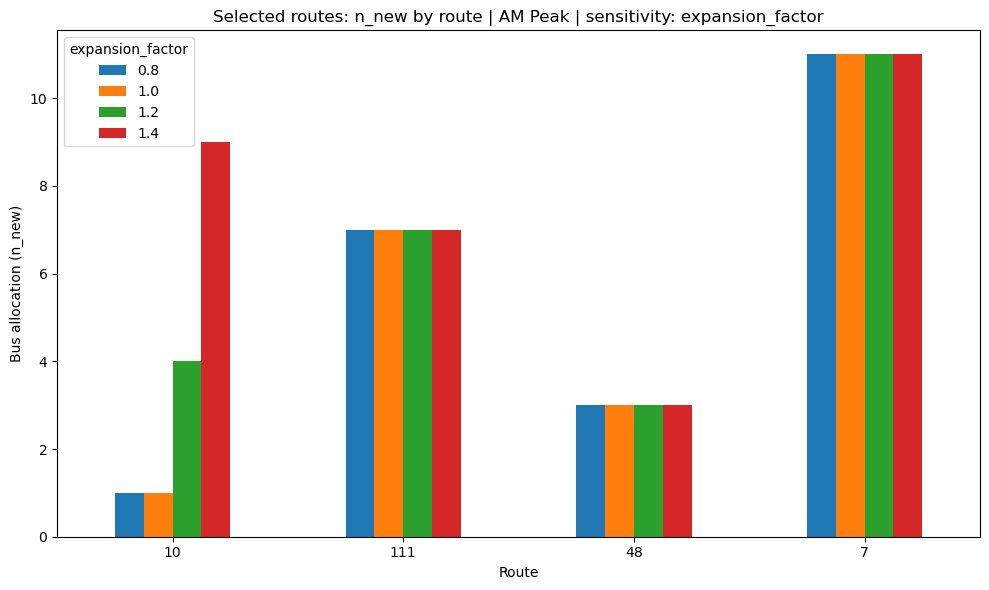

In [292]:
plot_all_routes_bar(
    solution_results=solution_results,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
    sort_routes_numeric=GRAPH_SETUP['sort_routes_numeric'],
)

plot_selected_routes_bar(
    solution_results=solution_results,
    parameter_name=SENSITIVITY_SETUP['parameter_name'],
    routes_of_interest=ROUTES_OF_INTEREST,
    time_block=GRAPH_SETUP['time_block'],
    value_col=GRAPH_SETUP['value_col'],
)